In [1]:
import pandas as pd

df = pd.read_csv('e_commerce_store.csv')

In [2]:
df.describe()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
count,698.000000,698.000000,698.000000,698.000000,698.000000
mean,7358.320559,2488.094527,226.717765,12.757794,3.663438
std,3094.972508,1004.723565,98.300869,6.818527,0.651065
min,1254.220000,401.080000,50.000000,1.010000,1.860000
25%,4966.182500,1717.845000,148.000000,6.580000,3.212500
50%,7355.240000,2458.860000,225.000000,12.910000,3.650000
75%,9862.620000,3289.300000,307.000000,18.790000,4.150000
max,13641.030000,4455.560000,399.000000,24.890000,5.000000


In [3]:
!pip install scikit-learn
!pip install joblib
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.2 MB/s  0:00:00


In [5]:
"""
Step-by-Step Machine Learning Regression Model for Profit Prediction
Educational Code - Execute Each Section Separately
"""

import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
import pandas as pd
import numpy as np
from faker import Faker

# Set random seed for reproducibility
np.random.seed(42)
fake = Faker()

print("="*70)
print("MACHINE LEARNING REGRESSION MODEL - STEP BY STEP TUTORIAL")
print("="*70)

MACHINE LEARNING REGRESSION MODEL - STEP BY STEP TUTORIAL


# ============================================================================
# STEP 1: LOAD YOUR ORIGINAL DATASET
# ============================================================================

In [9]:
print("\n" + "="*70)
print("STEP 1: LOAD ORIGINAL DATASET (670 entries)")
print("="*70)

# Original dataset (670 rows)
data_original = {
	'Sales': np.random.normal(45000, 15000, 670),
	'Units Sold': np.random.normal(340, 100, 670),
	'Discount (%)': np.random.normal(15, 8, 670),
	'Customer Rating': np.random.normal(4.1, 0.8, 670),
}
df_original = pd.DataFrame(data_original)
df_original['Profit'] = df_original['Sales'] * 0.3 + np.random.normal(0, 1000, 670)

print(f"✓ Original dataset loaded successfully")
print(f"✓ Original dataset shape: {df_original.shape}")
print(f"\nFirst 5 rows:")
print(df_original.head())

print(f"\nBasic Statistics (Original):")
print(df_original.describe())


STEP 1: LOAD ORIGINAL DATASET (670 entries)
✓ Original dataset loaded successfully
✓ Original dataset shape: (670, 5)

First 5 rows:
          Sales  Units Sold  Discount (%)  Customer Rating        Profit
0  52450.712295  464.608519     16.284592         2.813952  16414.356464
1  42926.035482  132.660977     15.024368         3.489820  12575.765145
2  54715.328072  305.731241     18.495505         3.484686  16085.150635
3  67845.447846  302.855913     24.525170         3.348078  21085.505058
4  41487.699379  199.248831     22.596433         4.763580  12781.367843

Basic Statistics (Original):
               Sales  Units Sold  Discount (%)  Customer Rating        Profit
count     670.000000  670.000000    670.000000       670.000000    670.000000
mean    44891.558961  348.276755     15.438666         4.099761  13471.820027
std     14811.673387   97.836853      7.974325         0.781147   4628.123186
min     -3619.010101   50.374462     -8.523109         1.684390   -445.223235
25%     

# ============================================================================
# STEP 2: EXPAND DATASET (SYNTHETIC DATA)
# ============================================================================

In [10]:
print("\n" + "="*70)
print("STEP 2: EXPAND DATASET WITH SYNTHETIC DATA (~5000 entries)")
print("="*70)

def generate_synthetic_data(n, df_ref):
	"""Generate synthetic data based on reference dataframe statistics."""
	data = {
    	'Sales': np.random.normal(df_ref['Sales'].mean(), df_ref['Sales'].std(), n),
    	'Units Sold': np.random.normal(df_ref['Units Sold'].mean(), df_ref['Units Sold'].std(), n),
    	'Discount (%)': np.random.normal(df_ref['Discount (%)'].mean(), df_ref['Discount (%)'].std(), n),
    	'Customer Rating': np.random.normal(df_ref['Customer Rating'].mean(), df_ref['Customer Rating'].std(), n),
	}
	df_syn = pd.DataFrame(data)
	# Approximate Profit as correlated with Sales + noise
	df_syn['Profit'] = df_syn['Sales'] * 0.3 + np.random.normal(0, 1000, n)
	return df_syn

df_synthetic = generate_synthetic_data(5000, df_original)

# Concatenate original + synthetic
df_expanded = pd.concat([df_original, df_synthetic], ignore_index=True)

print(f"✓ Expanded dataset shape: {df_expanded.shape}")
print(f"\nFirst 5 rows of expanded dataset:")
print(df_expanded.head())

print(f"\nBasic Statistics (Expanded):")
print(df_expanded.describe())


STEP 2: EXPAND DATASET WITH SYNTHETIC DATA (~5000 entries)
✓ Expanded dataset shape: (5670, 5)

First 5 rows of expanded dataset:
          Sales  Units Sold  Discount (%)  Customer Rating        Profit
0  52450.712295  464.608519     16.284592         2.813952  16414.356464
1  42926.035482  132.660977     15.024368         3.489820  12575.765145
2  54715.328072  305.731241     18.495505         3.484686  16085.150635
3  67845.447846  302.855913     24.525170         3.348078  21085.505058
4  41487.699379  199.248831     22.596433         4.763580  12781.367843

Basic Statistics (Expanded):
               Sales   Units Sold  Discount (%)  Customer Rating        Profit
count    5670.000000  5670.000000   5670.000000      5670.000000   5670.000000
mean    44583.757099   348.274448     15.616688         4.091871  13375.509738
std     15117.837032    96.307478      8.030047         0.783208   4670.107882
min    -11935.729920   -35.478541    -13.549602         1.087364  -5286.007910
25%   

In [11]:
df = df_expanded.copy()

============================================================================
# STEP 3: PREPARE FEATURES (X) AND TARGET (y)
# ============================================================================

In [13]:
print("\n" + "="*70)
print("STEP 3: PREPARE FEATURES AND TARGET VARIABLE")
print("="*70)

# Define features (independent variables)
feature_columns = ['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']
X = df[feature_columns].copy()

# Define target (dependent variable)
y = df['Profit'].copy()

print(f"Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {list(X.columns)}")

print(f"\nTarget (y):")
print(f"  Shape: {y.shape}")
print(f"  Variable: Profit")


STEP 3: PREPARE FEATURES AND TARGET VARIABLE
Features (X):
  Shape: (5670, 4)
  Columns: ['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']

Target (y):
  Shape: (5670,)
  Variable: Profit


# ============================================================================
# STEP 4: SPLIT DATA INTO TRAIN, VALIDATION, AND TEST SETS
# ============================================================================

In [14]:
print("\n" + "="*70)
print("STEP 4: SPLIT DATA (80% Train, 10% Validation, 10% Test)")
print("="*70)

# First split: separate test set (10% of total)
X_temp, X_test, y_temp, y_test = train_test_split(
	X, y, test_size=0.1, random_state=42
)
print(f"✓ Test set separated: {len(X_test)} samples (~10%)")

# Second split: split remaining 90% into train (80/90 ≈ 88.89%) and val (10/90 ≈ 11.11%)
val_ratio = 0.1111  # 10% of total from remaining 90%
X_train, X_val, y_train, y_val = train_test_split(
	X_temp, y_temp, test_size=val_ratio, random_state=42
)

print(f"✓ Training set: {len(X_train)} samples (~80%)")
print(f"✓ Validation set: {len(X_val)} samples (~10%)")
print(f"✓ Test set: {len(X_test)} samples (~10%)")

print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")


STEP 4: SPLIT DATA (80% Train, 10% Validation, 10% Test)
✓ Test set separated: 567 samples (~10%)
✓ Training set: 4536 samples (~80%)
✓ Validation set: 567 samples (~10%)
✓ Test set: 567 samples (~10%)

Total samples: 5670


# ============================================================================
# STEP 5: STANDARDIZE FEATURES (SCALING)
# ============================================================================

In [17]:
print("\n" + "="*70)
print("STEP 5: STANDARDIZE FEATURES")
print("="*70)

print("Creating StandardScaler...")
scaler = StandardScaler()

print("Fitting scaler on training data...")
scaler.fit(X_train)
print("✓ Scaler fitted")

print("\nTransforming training set...")
X_train_scaled = scaler.transform(X_train)
print(f"✓ Training set scaled: {X_train_scaled.shape}")

print("Transforming validation set...")
X_val_scaled = scaler.transform(X_val)
print(f"✓ Validation set scaled: {X_val_scaled.shape}")

print("Transforming test set...")
X_test_scaled = scaler.transform(X_test)
print(f"✓ Test set scaled: {X_test_scaled.shape}")

print("\nScaling completed! All features now have mean=0 and std=1")


STEP 5: STANDARDIZE FEATURES
Creating StandardScaler...
Fitting scaler on training data...
✓ Scaler fitted

Transforming training set...
✓ Training set scaled: (4536, 4)
Transforming validation set...
✓ Validation set scaled: (567, 4)
Transforming test set...
✓ Test set scaled: (567, 4)

Scaling completed! All features now have mean=0 and std=1


# ============================================================================
# STEP 6: TRAIN MODEL WITH MULTIPLE EPOCHS AND CROSS-VALIDATION
# ============================================================================

In [18]:
print("\n" + "="*70)
print("STEP 6: TRAIN MODEL (10 EPOCHS WITH 3-FOLD CROSS-VALIDATION)")
print("="*70)

# Initialize model
model = LinearRegression()
print("✓ Linear Regression model initialized")

# Training parameters
n_epochs = 10
n_folds = 3

# Storage for metrics
train_rmse_list = []
val_rmse_list = []
epoch_cv_results = []

# Create KFold object for cross-validation
kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f"\nStarting training: {n_epochs} epochs with {n_folds}-fold cross-validation")
print(f"Sleep time between epochs: 5 seconds\n")

# Training loop
for epoch in range(1, n_epochs + 1):
    print("-" * 70)
    print(f"EPOCH {epoch}/{n_epochs}")
    print("-" * 70)
    
    # Store fold results for this epoch
    fold_train_scores = []
    fold_val_scores = []
    
    # Perform k-fold cross-validation
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled), 1):
        # Split data for this fold
        X_fold_train = X_train_scaled[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train_scaled[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model on this fold
        model.fit(X_fold_train, y_fold_train)
        
        # Predict
        y_fold_train_pred = model.predict(X_fold_train)
        y_fold_val_pred = model.predict(X_fold_val)
        
        # Calculate RMSE
        fold_train_rmse = np.sqrt(mean_squared_error(y_fold_train, y_fold_train_pred))
        fold_val_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_val_pred))
        
        fold_train_scores.append(fold_train_rmse)
        fold_val_scores.append(fold_val_rmse)
        
        print(f"  Fold {fold_idx}/{n_folds} - Train RMSE: {fold_train_rmse:.2f}, Val RMSE: {fold_val_rmse:.2f}")
    
    # Calculate average RMSE across folds
    avg_train_rmse = np.mean(fold_train_scores)
    avg_val_rmse = np.mean(fold_val_scores)
    
    train_rmse_list.append(avg_train_rmse)
    val_rmse_list.append(avg_val_rmse)
    
    print(f"\n  EPOCH {epoch} AVERAGE:")
    print(f"	Train RMSE: {avg_train_rmse:.2f}")
    print(f"	Val RMSE: {avg_val_rmse:.2f}")
    
    # CALLBACK: Check for overfitting
    overfitting_threshold = 1.15  # Val RMSE > 1.15 * Train RMSE
    if avg_val_rmse > (avg_train_rmse * overfitting_threshold):
        print(f"\n  ⚠️  WARNING: POTENTIAL OVERFITTING DETECTED!")
        print(f"  	Validation RMSE is {(avg_val_rmse/avg_train_rmse):.2f}x higher than Training RMSE")
        print(f"  	Consider regularization or early stopping")
    else:
        print(f"\n  ✓ No overfitting detected (Val/Train ratio: {(avg_val_rmse/avg_train_rmse):.2f})")
    
    # Train final model on full training set for this epoch
    model.fit(X_train_scaled, y_train)
    
    # Sleep between epochs (as requested)
    if epoch < n_epochs:
        print(f"\n  Sleeping for 5 seconds before next epoch...")
        time.sleep(5)

print("\n" + "="*70)
print("✓ TRAINING COMPLETED!")
print("="*70)


STEP 6: TRAIN MODEL (10 EPOCHS WITH 3-FOLD CROSS-VALIDATION)
✓ Linear Regression model initialized

Starting training: 10 epochs with 3-fold cross-validation
Sleep time between epochs: 5 seconds

----------------------------------------------------------------------
EPOCH 1/10
----------------------------------------------------------------------
  Fold 1/3 - Train RMSE: 982.48, Val RMSE: 963.70
  Fold 2/3 - Train RMSE: 977.87, Val RMSE: 973.07
  Fold 3/3 - Train RMSE: 966.93, Val RMSE: 994.35

  EPOCH 1 AVERAGE:
	Train RMSE: 975.76
	Val RMSE: 977.04

  ✓ No overfitting detected (Val/Train ratio: 1.00)

  Sleeping for 5 seconds before next epoch...
----------------------------------------------------------------------
EPOCH 2/10
----------------------------------------------------------------------
  Fold 1/3 - Train RMSE: 982.48, Val RMSE: 963.70
  Fold 2/3 - Train RMSE: 977.87, Val RMSE: 973.07
  Fold 3/3 - Train RMSE: 966.93, Val RMSE: 994.35

  EPOCH 2 AVERAGE:
	Train RMSE: 975.76

# ============================================================================
# STEP 7: VISUALIZE TRAINING PROGRESS
# ============================================================================


STEP 7: VISUALIZE TRAINING PROGRESS
✓ Training progress plot saved as 'training_progress.png'


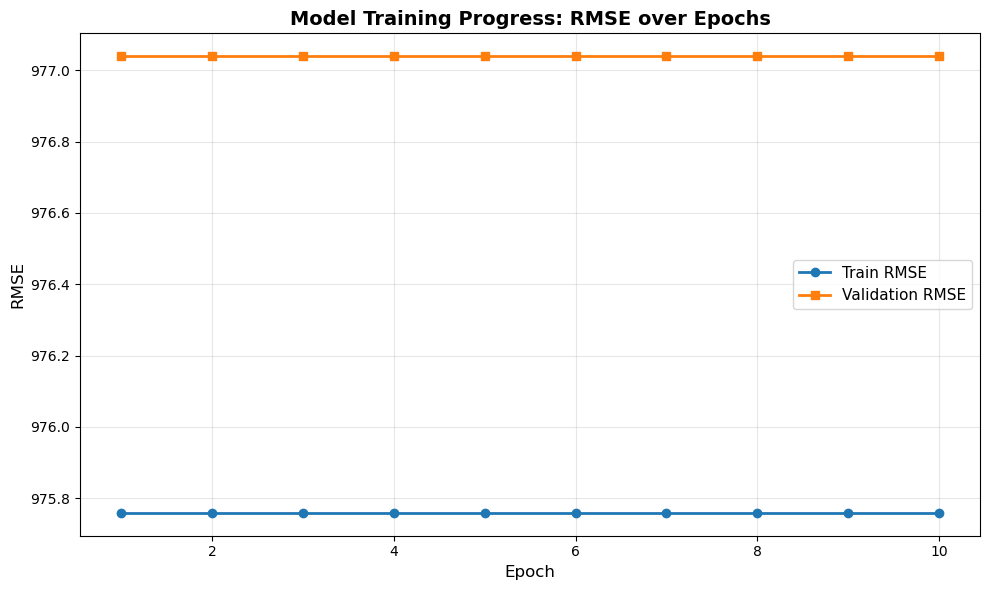

In [19]:
print("\n" + "="*70)
print("STEP 7: VISUALIZE TRAINING PROGRESS")
print("="*70)

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs+1), train_rmse_list, marker='o', label='Train RMSE', linewidth=2)
plt.plot(range(1, n_epochs+1), val_rmse_list, marker='s', label='Validation RMSE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Model Training Progress: RMSE over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_progress.png', dpi=300)
print("✓ Training progress plot saved as 'training_progress.png'")
plt.show()

# ========================================
# STEP 8: EVALUATE AND VISUALIZE PREDICTIONS
# ========================================


STEP 8: EVALUATE MODEL ON VALIDATION SET

Validation Set Performance:
  RMSE: 993.22
  MAE:  796.92
  R²:   0.9579

Generating Scatter Plot: Actual vs Predicted...
✓ Scatter plot saved as 'actual_vs_predicted_scatter.png'


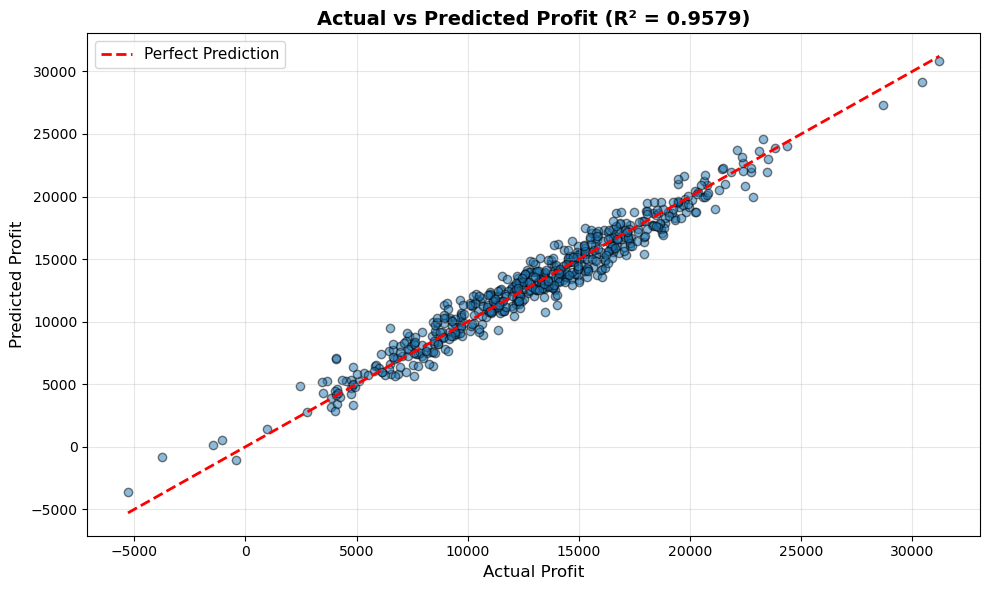


Generating Residual Plot...
✓ Residual plot saved as 'residual_plot.png'


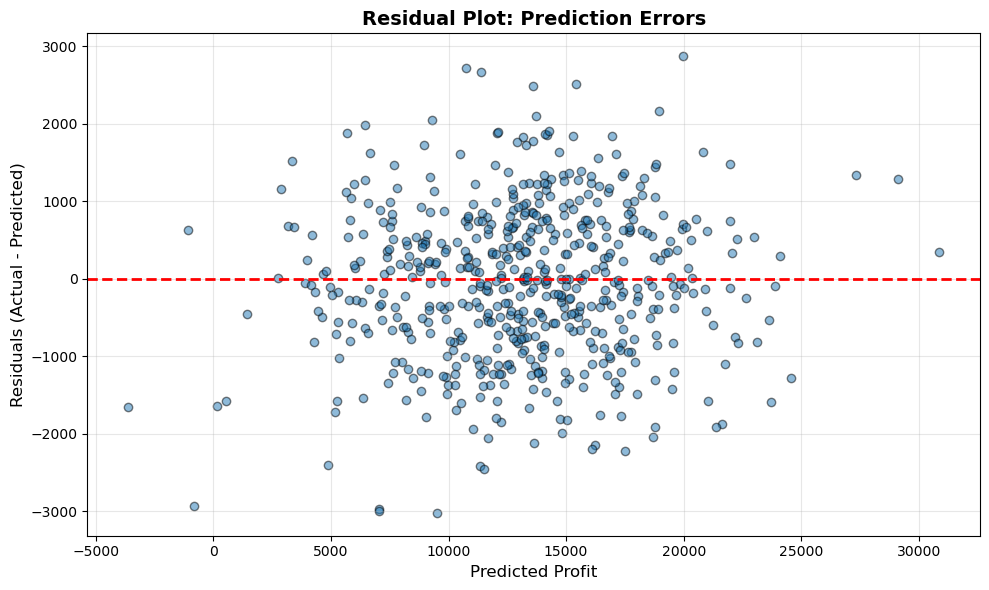


Generating Error Distribution Histogram...
✓ Error histogram saved as 'error_histogram.png'


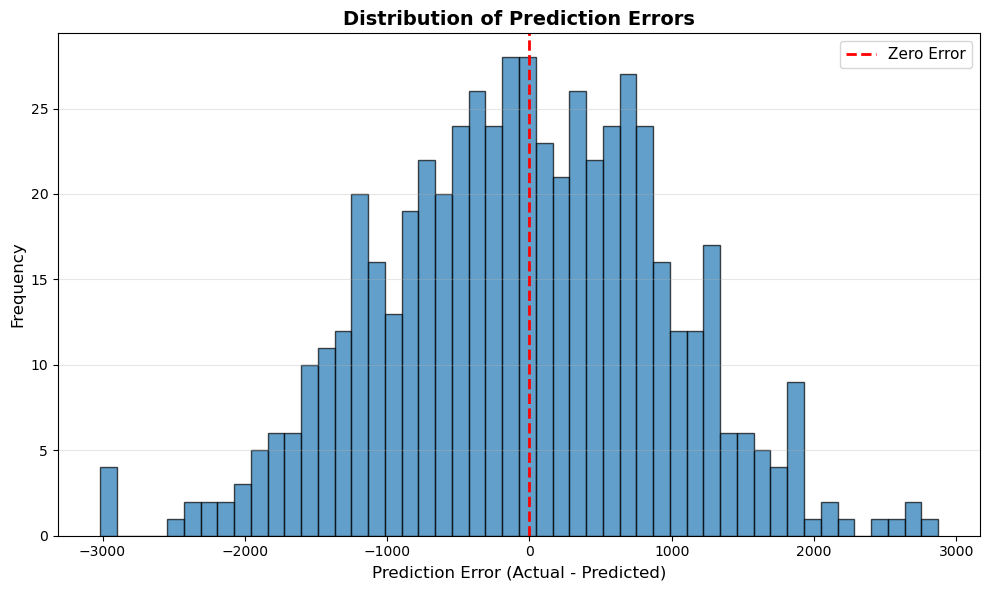


Generating Sample Comparison Plot (First 50 Samples)...
✓ Sample comparison plot saved as 'sample_comparison.png'


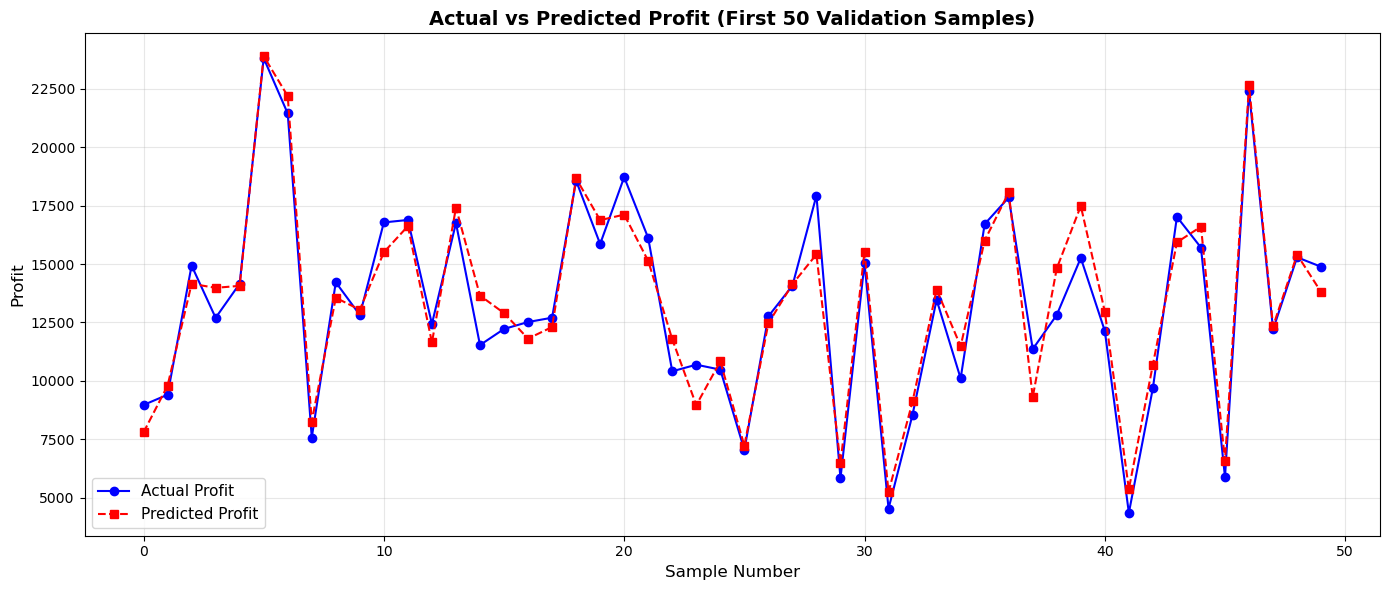


✓ ALL VISUALIZATIONS COMPLETED!


In [20]:
print("\n" + "="*70)
print("STEP 8: EVALUATE MODEL ON VALIDATION SET")
print("="*70)

# Predict on validation set
y_val_pred = model.predict(X_val_scaled)

# Calculate metrics
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"\nValidation Set Performance:")
print(f"  RMSE: {val_rmse:.2f}")
print(f"  MAE:  {val_mae:.2f}")
print(f"  R²:   {val_r2:.4f}")

# ========================================
# VISUALIZATION 1: SCATTER PLOT (ACTUAL VS PREDICTED)
# ========================================
print("\nGenerating Scatter Plot: Actual vs Predicted...")

plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_val_pred, alpha=0.5, edgecolors='k')

# Add perfect prediction line (diagonal)
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Profit', fontsize=12)
plt.ylabel('Predicted Profit', fontsize=12)
plt.title(f'Actual vs Predicted Profit (R² = {val_r2:.4f})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted_scatter.png', dpi=300)
print("✓ Scatter plot saved as 'actual_vs_predicted_scatter.png'")
plt.show()

# ========================================
# VISUALIZATION 2: RESIDUAL PLOT (ERROR DISTRIBUTION)
# ========================================
print("\nGenerating Residual Plot...")

residuals = y_val - y_val_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_val_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Profit', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Prediction Errors', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300)
print("✓ Residual plot saved as 'residual_plot.png'")
plt.show()

# ========================================
# VISUALIZATION 3: ERROR HISTOGRAM
# ========================================
print("\nGenerating Error Distribution Histogram...")

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('error_histogram.png', dpi=300)
print("✓ Error histogram saved as 'error_histogram.png'")
plt.show()

# ========================================
# VISUALIZATION 4: FIRST 50 SAMPLES COMPARISON (OPTIONAL)
# ========================================
print("\nGenerating Sample Comparison Plot (First 50 Samples)...")

n_samples = min(50, len(y_val))
sample_indices = range(n_samples)

plt.figure(figsize=(14, 6))
plt.plot(sample_indices, y_val.values[:n_samples], marker='o', linestyle='-',
     	color='blue', label='Actual Profit', markersize=6)
plt.plot(sample_indices, y_val_pred[:n_samples], marker='s', linestyle='--',
     	color='red', label='Predicted Profit', markersize=6)
plt.xlabel('Sample Number', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.title(f'Actual vs Predicted Profit (First {n_samples} Validation Samples)',
      	fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sample_comparison.png', dpi=300)
print("✓ Sample comparison plot saved as 'sample_comparison.png'")
plt.show()

print("\n" + "="*70)
print("✓ ALL VISUALIZATIONS COMPLETED!")
print("="*70)

# ============================================================================
# STEP 9: SAVE TRAINED MODEL AND SCALER
# ============================================================================

In [21]:
print("\n" + "="*70)
print("STEP 9: SAVE MODEL AND SCALER")
print("="*70)

print("Saving trained model...")
joblib.dump(model, 'profit_prediction_model.pkl')
print("✓ Model saved as 'profit_prediction_model.pkl'")

print("Saving scaler...")
joblib.dump(scaler, 'feature_scaler.pkl')
print("✓ Scaler saved as 'feature_scaler.pkl'")

print("\nModel artifacts saved successfully!")


STEP 9: SAVE MODEL AND SCALER
Saving trained model...
✓ Model saved as 'profit_prediction_model.pkl'
Saving scaler...
✓ Scaler saved as 'feature_scaler.pkl'

Model artifacts saved successfully!
